## Datasci 530 - Assignment 3
### Analysis of Artificial Intelligence Research Using OpenAlex

Joelle Millar
September 2026


## Overview

This analysis uses the OpenAlex Works API to examine the growth and geographical distribution of research publications with "artificial intelligence" in their titles. Since 2000, the number of publications using AI-related terminology has changed substantially, alongside increasing use of terms such as "LLM", "GPT", and "deep learning". The analysis also shows differences in the geographical distribution of AI research and changes in the relative contribution of major publishing countries over time. Together, the results illustrate both the rapid growth of AI-related research and changes in the terminology and geographical distribution of the field.

Notably, it finds that there have been 333,848 works published with the phrase "artificial intelligence" in the title, since 2000, and that the United States and China are the countries leading the number of publications. In the additional analysis, we see that the US has been consistently among the countries publishing papers related to AI, but India was accounted for 0% of papers published in the year 2000 and in 2025, it accounted for almost 8% of papers published.

### 1. Set Up & API Access

Imports packages used throughout the analysis and initiate global variables for use throughout the analysis.

In [55]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# OpenAlex endpoint for retrieving information
URL = "https://api.openalex.org/works"

# Time period for the analysis
START_YEAR = 2000
END_YEAR = pd.Timestamp.today().year
YEARS = list(range(START_YEAR, END_YEAR + 1))

# Main search phrase used throughout the analysis
AI = "artificial intelligence"

# Personal OpenAlex API key used to allow a larger number of API requests
API_KEY = "u5rDnmFvVmOVtU3WF41fV6"


The OpenAlex API returns grouped results in JSON format. The below function provides a consistent way to retrieve and clean these grouped results before they are used in the analysis. It checks that the expected data are present, removes missing or unknown groups, converts counts to numeric values, and returns the results as a DataFrame.

Using this function avoids displaying raw API responses and ensures that the grouped data used in later sections have been checked and cleaned consistently.

In [56]:
def get_grouped_results(params):
    """
    Retrieve grouped results from OpenAlex and return
    the group data as a DataFrame.
    """
    
    response = requests.get(URL, params=params)
    response.raise_for_status()
    
    data = response.json()
    
    # Check that the expected grouped results are present
    assert "group_by" in data, "Grouped results not returned by OpenAlex"
    
    groups = pd.DataFrame(data["group_by"])
    
    assert not groups.empty, "No grouped results returned"
    assert "key" in groups.columns, "Group identifiers are missing"
    assert "count" in groups.columns, "Group counts are missing"
    
    # Remove missing/unknown groups
    groups = groups[
        groups["key"].notna() &
        (groups["key"].str.lower() != "unknown")
    ].copy()
    
    # Ensure counts are numeric
    groups["count"] = pd.to_numeric(groups["count"], errors="coerce")
    
    assert groups["count"].notna().all(), "Some group counts are not numeric"
    
    return groups

### 2. Number of AI-Titled Works

Search the OpenAlex Works API for publications whose titles contain the phrase "artificial intelligence". 

The API's title search filter is used so that the search is restricted to publication titles rather than abstracts, keywords, or other metadata.

Per_page only requests one record because we are interested in the total number of matching works, which is returned in the API meta data.

In [57]:
# Searches the OpenAlex Works API for publications with titles containing "artificial intelligence"

# Search Parameters

params = {
    # Per_page is set to 1 because the total number of matching works is provided separately in the API meta data
    "filter": f'title.search:"{AI}"',
    "per_page": 1,
    "api_key": API_KEY,
}

response = requests.get(URL, params=params)

# Stop the analysis if the API request was unsuccessful
response.raise_for_status()

data = response.json()

# Validate the expected metadata is present
assert "meta" in data, "OpenAlex metadata missing"
assert "count" in data["meta"], "Total count missing from OpenAlex response"

# OpenAlex reports the total number of matching works in the meta data
ai_title_count = data["meta"]["count"]

# Displays total number of works
print(
    f"Total works with '{AI}' in the title:", 
    f"{ai_title_count:,}"
)

Total works with 'artificial intelligence' in the title: 333,848


### 3. Geographical Distribution of AI Research

Restricts the search to publications that were released from 2000 onwards, and groups the works according to the countries represented in their authors' institutional affiliations.

A publication with authors from multiple countries can be counted once for each represented country.

There are fewer than 200 countries in the world, so setting per_page to return 200 countries will ensure that none are missed out, without unnecessarily asking for too many.

Because there are many countries represented in the results, I display the top 25 countries in the final table, while retaining the complete country-level dataset for later analysis.

In [58]:
# Search Parameters
params = {
    "filter": 'title.search:"artificial intelligence",from-publication-date:2000-01-01',
    "group_by": "authorships.countries",
    "per_page": 200,
    "api_key": API_KEY,   
}

# Retrieve the results and clean the data
countries = get_grouped_results(params)

# Extract the two-letter country code from the identifier
countries["country_code"] = (
    countries["key"]
    .str.split("/")
    .str[-1]
    .str.upper()
)

# Check that country codes were successfully extracted
assert countries["country_code"].notna().all(), "Missing country codes"

# Sort countries from the largest to smallest number of publications
# and rename columns
countries = (
    countries
    .sort_values("count", ascending=False)
    .rename(columns={
        "key_display_name": "Country", 
        "count": "Number of works"
        })
        [["Country", "country_code", "Number of works"]]
    .reset_index(drop=True)
)

# Add a rank column, beginning from 1
countries.insert(0, "Rank", range(1, len(countries) + 1))

# Display top 25 results
display(
    countries.head(25)[
        ["Rank", "Country", "Number of works"]
    ]
    .style
    .hide(axis="index")
    .format({"Number of works": "{:,}"})
    .set_caption(
        "Table 2. Top 25 countries by number of AI-titled works since 2000"
    )
)

Rank,Country,Number of works
1,United States,"37,241"
2,China,"30,124"
3,India,"25,011"
4,United Kingdom,"12,734"
5,Indonesia,"9,434"
6,Italy,"7,470"
7,Germany,"6,925"
8,Turkey,"6,718"
9,Russia,"5,968"
10,Canada,"5,915"


### 4. Most Highly Cited AI-Titled Works

Returns the 10 papers which have cited most from the OpenAlex request since 2000. 

Some highly cited papers have many authors and institutions, to keep the final 
table readable, the first six authors and institutions have been displayed, and it indicates when additional entries exist.



In [59]:
params = {
    "filter": 'title.search:"artificial intelligence",from-publication-date:2000-01-01',
    "sort": "cited_by_count:desc",
    "per_page": 10,
    "select": "id,title,publication_year,cited_by_count,authorships",
    "api_key": API_KEY,
}

response = requests.get(URL, params=params)
response.raise_for_status()

results = response.json()["results"]

# Check that the expected number of works was returned
assert len(results) == 10, "Expected 10 highly cited works"

rows = []

for rank, work in enumerate(results, start=1):
    
    # Extract author names
    authors = [
        a["author"]["display_name"]
        for a in work["authorships"]
        if a.get("author") and a["author"].get("display_name")
    ]

    # Extract unique institutions
    institutions = []

    for authorship in work["authorships"]:
        for institution in authorship.get("institutions", []):
            name = institution.get("display_name")
            
            if name and name not in institutions:
                institutions.append(name)

    # Format authors
    authors_display = "; ".join(authors[:6])
    
    if len(authors) > 6:
        authors_display += f"; et al. ({len(authors)} authors)"

    # Format institutions
    if institutions:
        institutions_display = "; ".join(institutions[:6])
        
        if len(institutions) > 6:
            institutions_display += f"; +{len(institutions) - 6} more"
    else:
        institutions_display = "Not reported"

    rows.append({
        "Rank": rank,
        "Title": work.get("title"),
        "Year": work.get("publication_year"),
        "Citations": work.get("cited_by_count", 0),
        "Authors": authors_display,
        "Institutions": institutions_display,
    })

top10 = pd.DataFrame(rows)

# Quality checks
assert len(top10) == 10, "Expected 10 highly cited works"
assert top10["Title"].notna().all(), "Some titles are missing"
assert top10["Citations"].notna().all(), "Some citation counts are missing"

display(
    top10
    .style
    .hide(axis="index")
    .format({"Citations": "{:,}"})
    .set_properties(**{
        "text-align": "left",
        "white-space": "pre-wrap",
        "vertical-align": "top"
    })
    .set_caption(
        "Table 3. Ten most cited works with 'artificial intelligence' "
        "in the title (2000 onward)"
    )
)

Rank,Title,Year,Citations,Authors,Institutions
1,High-performance medicine: the convergence of human and artificial intelligence,2018,"10,279",Eric J. Topol,Scripps Research Institute
2,"Explainable Artificial Intelligence (XAI): Concepts, taxonomies, opportunities and challenges toward responsible AI",2019,"10,137",Alejandro Barredo Arrieta; Natalia Díaz-Rodríguez; Javier Del Ser; Adrien Bennetot; Siham Tabik; Alberto Barbado; et al. (12 authors),Tecnalia; Institut national de recherche en sciences et technologies du numérique; École Nationale Supérieure de Techniques Avancées; École Nationale Supérieure de Techniques Avancées Paris; Unité d'Informatique et d'Ingénierie des Systèmes; Sorbonne Université; +4 more
3,Systematic review of research on artificial intelligence applications in higher education – where are the educators?,2019,"6,847",Olaf Zawacki‐Richter; Victoria I. Marín; Melissa Bond; Franziska Gouverneur,Carl von Ossietzky Universität Oldenburg
4,Peeking Inside the Black-Box: A Survey on Explainable Artificial Intelligence (XAI),2018,"6,290",Amina Adadi; Mohammed Berrada,Sidi Mohamed Ben Abdellah University
5,Proceedings of the 19th International Joint Conference on Artificial Intelligence,2005,"5,781",Josep M. Pujol; Jordi Delgado; Ramón Sangüesa; Andreas Flache,Not reported
6,Explanation in artificial intelligence: Insights from the social sciences,2018,"5,266",Tim Miller,The University of Melbourne
7,"Artificial intelligence in healthcare: past, present and future",2017,"4,901",Fei Jiang; Yong Jiang; Hui Zhi; Yi Dong; Hao Li; Sufeng Ma; et al. (12 authors),University of Hong Kong; Capital Medical University; Beijing Tian Tan Hospital; Fudan University; Huashan Hospital
8,"Artificial Intelligence (AI): Multidisciplinary perspectives on emerging challenges, opportunities, and agenda for research, practice and policy",2019,"4,526",Yogesh Kumar Dwivedi; Laurie Hughes; Elvira Ismagilova; Gert Aarts; Crispin R. Coombs; Tom Crick; et al. (35 authors),Prin. L. N. Welingkar Institute of Management Development and Research; Swansea University; University of Bradford; Loughborough University; University of Bedfordshire; Aston University; +12 more
9,"BNAI, NO-TOKEN, and MIND-UNITY: Pillars of a Systemic Revolution in Artificial Intelligence",2022,"4,271","Wei, Jason; Wang, Xuezhi; Dale Schuurmans; Maarten Bosma; Ichter, Brian; Xia, Fei; et al. (9 authors)",Google (United States)
10,Artificial Intelligence in Education: A Review,2020,"3,983",Lijia Chen; Pingping Chen; Zhijian Lin,Yango University; Fuzhou University


### 5. Trends in AI Research Terminology

Identifying how the number of publications with the phrase “artificial intelligence” changed year-to-year since 2000, and comparing this to the use of the terms “LLM” and “GPT”.

I chose "deep learning" as an additional keyword to analyse against, because it represents another major research concept within artificial intelligence.

Comparing it with "artificial intelligence", "LLM", and "GPT", allows the analysis to examine whether changes in AI research terminology have occurred at different rates.

The function yearly_counts retrieves the number of OpenAlex works published in each year (from START_YEAR to END_YEAR). 

The analysis includes 2026 becuase it is the current year when the data were retrieved. However, 2026 is incomplete, so its publication counts cannot be directly compared with completed years. The plots therefore shade 2026 to indicate that it represents a partial year.

A logarithmic scale is used to make relative changes easier to compare across the search terms, this highlights how quickly the use of different AI-related terms has grown.

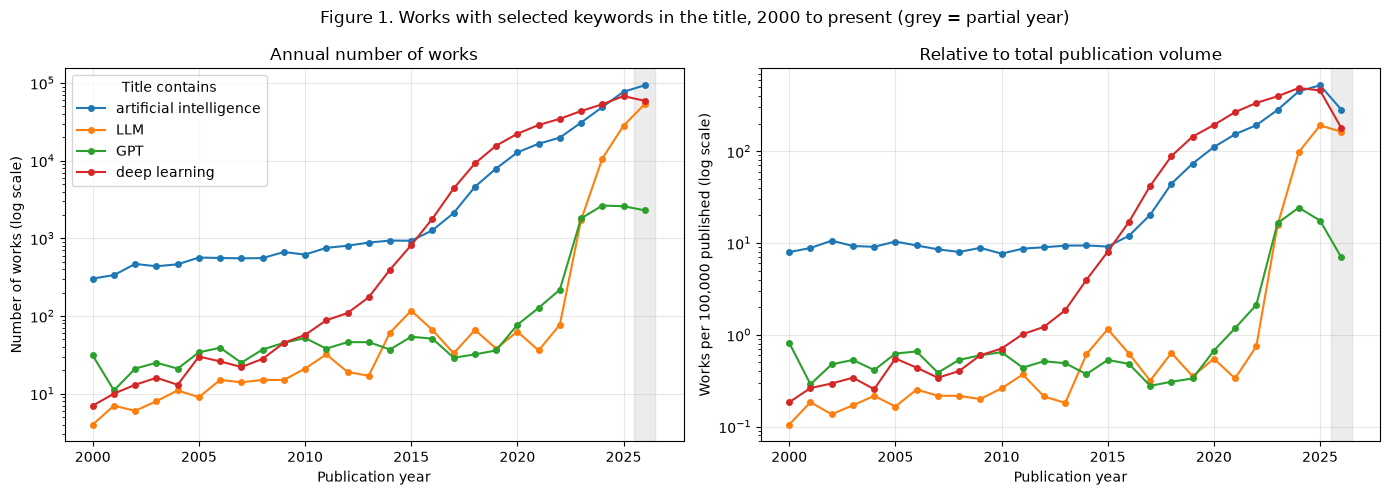

,artificial intelligence,LLM,GPT,deep learning,AI year-over-year change (%)
2000,303,4,31,7,+nan
2005,565,9,34,30,+22.0
2010,617,21,52,57,-7.4
2015,930,117,54,816,-0.5
2020,"12,760",63,77,"22,192",+61.1
2025,"77,047","28,175","2,586","67,750",+57.5


In [60]:
# Define search terms 
terms = ["artificial intelligence", "LLM", "GPT", "deep learning"]

# extra_filter allows for optional OpenAlex filters to be used when retrieving the JSON response
def yearly_counts(extra_filter=""):

    # Start with a publication year filter covering the full analysis period (from 2000)
    flt = f"publication_year:{START_YEAR}-{END_YEAR}"

    # Add additional filter when analysing a specific keyword
    if extra_filter:
        flt += "," + extra_filter

    params = {
        "filter": flt, 
        "group_by": "publication_year",
        "per_page": 200, 
        "api_key": API_KEY
    }

    response = requests.get(URL, params=params)

    # Stop the analysis if the API request was unsuccessful
    response.raise_for_status()

    data = response.json()

    assert "group_by" in data, "Yearly groups missing from OpenAlex response"

    groups = data["group_by"]

    # Convert the grouped API response into a Series where:
    # index = publication_year, value = number of works
    yearly = pd.Series({
        int(group["key"]): group["count"] 
        for group in groups
    })

    # Ensure counts are numeric
    yearly = pd.to_numeric(yearly, errors="coerce")

    assert yearly.notna().all(), "Some yearly counts are not numeric"

    # Include every year in the analysis period
    return yearly.reindex(YEARS, fill_value=0)  

# Retrieve counts for each search term
counts = pd.DataFrame({
    term: yearly_counts(f'title.search:"{term}"')
    for term in terms
})

# Retrieve total number of works for each year
total_works = yearly_counts()

# Quality checks
assert counts.index.equals(pd.Index(YEARS))
assert counts.isna().sum().sum() == 0
assert total_works.isna().sum() == 0

# Calculate publications per 100,000 works
per100k = counts.div(total_works.replace(0, np.nan), axis=0) * 100_000

# Build the figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, ylabel, title in [
    (axes[0], counts, "Number of works (log scale)", "Annual number of works"),
    (axes[1], per100k, "Works per 100,000 published (log scale)", "Relative to total publication volume"),
]:
    for term in data.columns:
        ax.plot(data.index, data[term].replace(0, np.nan), marker="o", markersize=4, label=term)
    ax.set_yscale("log")
    ax.set_xlabel("Publication year")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3)

    # Compute 2026 as a partial year
    ax.axvspan(END_YEAR - 0.5, END_YEAR + 0.5, color="grey", alpha=0.15)
axes[0].legend(title="Title contains")
fig.suptitle("Figure 1. Works with selected keywords in the title, 2000 to present (grey = partial year)")
plt.tight_layout()
plt.show()

# Table: selected years + AI year-over-year growth
sel = [y for y in [2000, 2005, 2010, 2015, 2020, 2025] if y in counts.index]
table = counts.loc[sel].copy()
table["AI year-over-year change (%)"] = counts["artificial intelligence"].pct_change().mul(100).round(1).loc[sel]

# Display the table
display(table.style
        .format("{:,.0f}", subset=terms)
        .format("{:+.1f}", subset=["AI year-over-year change (%)"])
        .set_caption("Table 4. Annual counts for 5-year intervals from 2000 and AI year-over-year growth"))

### 6. Additional Analysis: Changing Geographical Distribution

The analysis in Section 4 produces a cumulative ranking of countries based on
the total number of AI-titled works published since 2000. While this shows which
countries have contributed the largest number of publications over the full
period, it does not show how their contribution has changed over time.

For the additional analysis, I examine the yearly share of AI-titled works that
include at least one author affiliated with each of the five countries that
rank highest in Section 4. This allows the analysis to compare the geographical
distribution of AI research across individual years rather than only looking at
the cumulative total.

The analysis uses whole counting. Therefore, an AI-titled work with authors
from multiple countries contributes to the share of every country represented
in its authorship affiliations.

This shows whether the relative contribution of the leading countries has
changed over time.

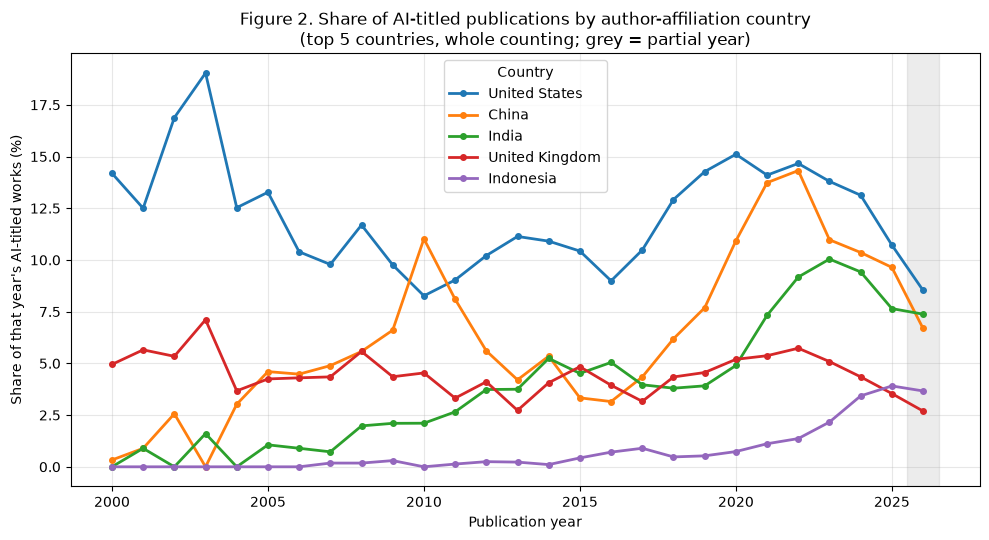

,United States,China,India,United Kingdom,Indonesia
2000,14.2,0.3,0.0,5.0,0.0
2005,13.3,4.6,1.1,4.2,0.0
2010,8.3,11.0,2.1,4.5,0.0
2015,10.4,3.3,4.5,4.8,0.4
2020,15.1,10.9,4.9,5.2,0.7
2025,10.7,9.6,7.6,3.5,3.9


In [62]:
# Top 5 countries from the cumulative ranking
top5 = countries.head(5)[["Country", "country_code"]]

# Retrieve yearly AI-titled work counts for each country
country_year = {}

for _, row in top5.iterrows():

    country = row["Country"]
    country_code = row["country_code"]

    flt = (
        f'title.search:"{AI}",'
        f'authorships.countries:{country_code}'
    )

    country_year[country] = yearly_counts(flt)

cy = pd.DataFrame(country_year)

# Check that all years and countries are present
assert cy.index.equals(pd.Index(YEARS))
assert cy.isna().sum().sum() == 0

# Calculate each country's share of AI-titled works
ai_total = counts[AI]

share = cy.div(
    ai_total.replace(0, np.nan),
    axis=0
) * 100

# Check that the resulting percentages are valid
assert (share >= 0).all().all()

# Display Graph
fig, ax = plt.subplots(figsize=(10, 5.5))
for country in share.columns:
    ax.plot(share.index, share[country], marker="o", markersize=4, linewidth=2, label=country)

# Compute 2026 as a partial year
ax.axvspan(END_YEAR - 0.5, END_YEAR + 0.5, color="grey", alpha=0.15)   # partial year
ax.set_xlabel("Publication year")
ax.set_ylabel("Share of that year's AI-titled works (%)")
ax.set_title("Figure 2. Share of AI-titled publications by author-affiliation country\n"
             "(top 5 countries, whole counting; grey = partial year)")
ax.legend(title="Country")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Display Table
sel = [y for y in [2000, 2005, 2010, 2015, 2020, 2025] if y in share.index]
display(share.loc[sel].style
        .format("{:.1f}")
        .set_caption("Table 5. Share (%) of each year's AI-titled works with at least one author from the country"))

### What we learn from this additional analysis

Figure 2 and Table 5 show changes in the geographical distribution of AI-titled research over time. In 2000, the United States appeared on 14.2% of AI-titled works and the United Kingdom on 5.0%, while China and India appeared on only 0.3% and 0.0%, respectively. By 2024, the United States accounted for 13.2% of AI-titled works, while China and India had increased to 10.4% and 9.5%. Indonesia also increased from 0.0% in 2000 to 3.4% in 2024.

This provides a different perspective from Section 3. The cumulative ranking measures the total number of AI-titled works associated with each country since 2000, whereas the yearly shares show how countries' contributions have changed over time. The cumulative ranking can conceal changes in the relative geographical distribution of research during the period.

The results have several limitations: the shares are calculated against all AI-titled works, including works for which country affiliation information is unavailable. In 2000, the five countries together account for only about 20% of AI-titled works, which suggests that missing affiliation information is particularly important in the earlier years. The low early shares may therefore reflect incomplete metadata as well as differences in research output.

Finally, some of the yearly series fluctuate substantially. For example, China's share changes from 4.6% in 2005 to 11.0% in 2010, 3.3% in 2015, and 10.9% in 2020. These fluctuations may partly reflect changes in the underlying publication and affiliation metadata, particularly for earlier years, and should therefore not automatically be interpreted as changes in the actual volume of research. The analysis is also based only on title matches for the phrase "artificial intelligence", so it does not capture AI research that uses different terminology in its title.